# 34 — `labels`

`Map.labels` writes **one string per feature**, taken from an attribute column. It is the layer that turns a map
of shapes into a map a reader can name things on — and the one most likely to ruin a figure if used carelessly,
because text does not shrink, overlap gracefully, or stay legible over a busy background.

By the end you will be able to label features from a column, size and colour the text, keep it readable over any
background with a halo, and nudge it off the feature with an offset.

API: [`Map.labels`](../../reference/static_map.md).

**Setup**.

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
from pyramids.feature import FeatureCollection

from digitalearth.static import Map

# The notebook's own folder is the kernel's working directory, so the bundled
# example data sits three levels up: docs/examples/plots -> repo root.
DATA = Path("../../../examples/data")


## The data

Germany's 16 states (a `shapeName` per polygon) and the 34 Rhine gauges (a `name` per point) — one polygon case
and one point case, which behave differently enough to be worth seeing both.

In [2]:
states = FeatureCollection.read_file(str(DATA / "germany_adm1.geojson"))
gauges = FeatureCollection.read_file(str(DATA / "rhine_gauges.geojson"))
print("states:", list(states["shapeName"][:4]))
print("gauges:", list(gauges["name"][:4]))

states: ['Baden-Württemberg', 'Bayern', 'Berlin', 'Brandenburg']
gauges: ['Plochingen', 'Lauffen', 'Rockenau', 'Maxau']


C:\python-environments\pixi\envs\digitalearth-4838541935417106159\envs\dev\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: Several features with id = 5 have been found. Altering it to be unique. This warning will not be emitted anymore for this layer
  return ogr_read(


## Quickstart — labelling polygons

`labels(features, column)` places each string at its feature's anchor point — the centroid, for a polygon. The
default text is white with a black halo, which is the combination that survives an arbitrary background.

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\base\points.py:222: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = geom.centroid


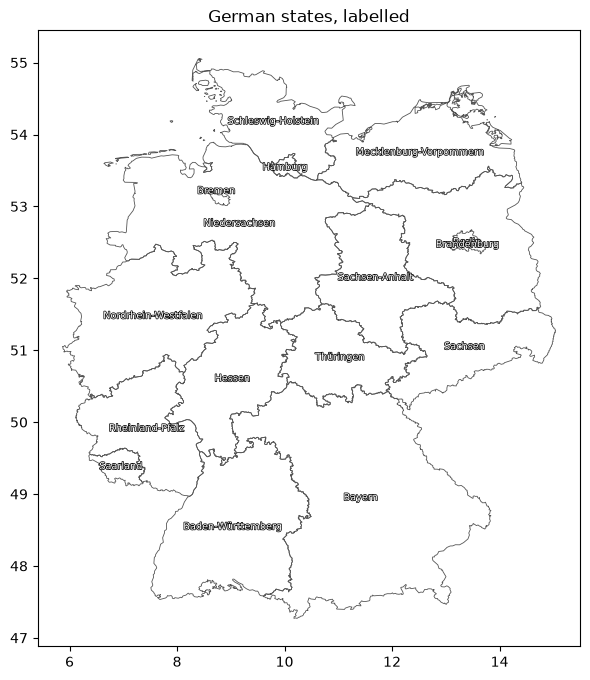

In [3]:
m = Map(crs=4326, figsize=(7, 8))
m.polygons(states, edgecolor="#555555", linewidth=0.6)
m.labels(states, "shapeName", text_size=7)
m.set_title("German states, labelled")
m.fig;

`text_size=7` rather than the default 12 is doing real work here: at 12 the long names (Mecklenburg-Vorpommern,
Nordrhein-Westfalen) collide with their neighbours. Labelling is always a negotiation with available space.

## Styling the text

Text colour, halo colour and halo width are separate arguments so the label can be tuned to its background
rather than to a theme.

| argument | meaning | typical value |
|---|---|---|
| `column` | attribute holding the text | a string column |
| `text_size` | font size in points | `12.0` default; drop it when labels crowd |
| `color` | text colour | `"#ffffff"` default |
| `halo_color` | outline colour drawn behind the glyphs | `"#000000"` default |
| `halo_width` | outline thickness | `1.0` default; `0` disables |
| `offset` | `(dx, dy)` shift in points, to clear the feature | `None` |

C:\gdrive\algorithms\serapeum-github-org\repos\visualization\Digital-Earth\src\digitalearth\base\points.py:222: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  geom = geom.centroid


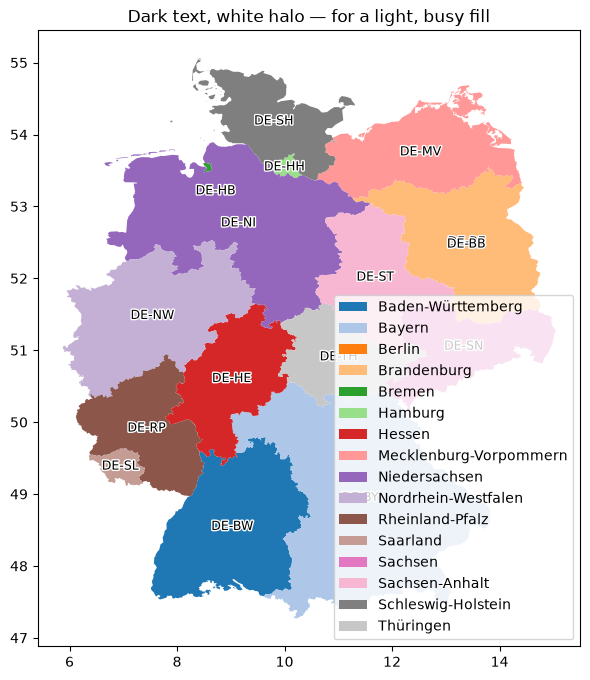

In [4]:
m = Map(crs=4326, figsize=(7, 8))
m.choropleth(states, "shapeName", scheme="categorical", cmap="tab20", legend=False)
m.labels(states, "shapeISO", text_size=9, color="black", halo_color="white", halo_width=2.0)
m.set_title("Dark text, white halo — for a light, busy fill")
m.fig;

Over a pale multi-colour fill the default white-on-black inverts badly, so black text in a white halo reads
better. The halo is what makes either choice work: without it the glyphs would disappear wherever they crossed a
fill of similar lightness.

## Labelling points, and nudging with `offset`

A point label placed at the anchor sits *on top of* its marker. `offset` shifts the text by a `(dx, dy)` in
points so the marker stays visible — the standard treatment for a labelled station network.

In [5]:
rhine_gauges = gauges[gauges["river"] == "RHEIN"]
print(f"{len(rhine_gauges)} gauges on the Rhein itself (of {len(gauges)} total)")

8 gauges on the Rhein itself (of 34 total)


Labelling all 34 gauges at once is unreadable, so this filters to the Rhine's own gauges first. Choosing *what
not to label* is most of the craft.

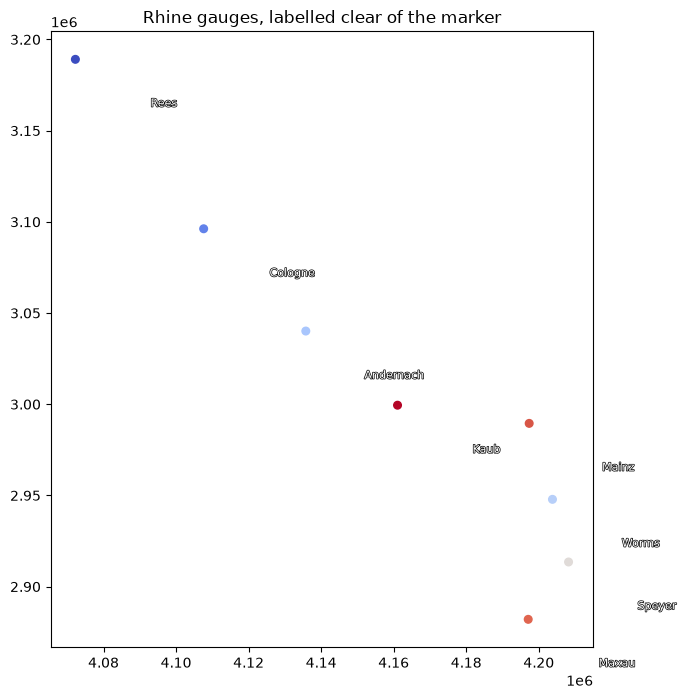

In [6]:
m = Map(crs=gauges.crs.to_epsg(), figsize=(7, 8))
m.points(rhine_gauges, size=30)
m.labels(rhine_gauges, "name", text_size=8, offset=(8, 4))
m.set_title("Rhine gauges, labelled clear of the marker")
m.fig;

Each name now sits up and to the right of its dot instead of over it. Compare the readability with what you
would get by labelling all 34 gauges including the tributaries — the filter did more for this figure than any
styling argument.

## Takeaway

- `labels(features, column)` writes one string per feature at its anchor — polygon centroid, or the point itself.
- `text_size` is usually the first thing to reduce; default 12 crowds quickly.
- The **halo** is what keeps text legible over an unknown background; match `color`/`halo_color` to the fill.
- `offset` moves point labels clear of their markers.
- Filtering which features get labelled matters more than any style argument.

That completes the plot gallery. For scene-level machinery — layers, insets, multi-panel figures — see
[`15_layer_management`](../15_layer_management.ipynb) onward.